# Mean to osculating elements

This notebooks demonstrates how to convert from the osculating elements used by the the TTV posteriors to the mean elements implicitly used when representing the phase space state of a given system. The [`celmech` package](https://celmech.readthedocs.io/en/latest/) is used to affect the transformation.

In [1]:
from resonantstate.data_download  import get_metadata_observations, download_observations_samples
from resonantstate.constants import *
dataframe_observations = get_metadata_observations()

We'll use the Kepler-11 system as an example

In [2]:
star='Kepler-11'
dataframe_system = dataframe_observations[(dataframe_observations["star_name"]==star)]

dataframe_system_dl = dataframe_system[(dataframe_system['author_name']=='Hadden')&(dataframe_system['default']==True)]
list_analysis = download_observations_samples(dataframe_system_dl, download_destination=None)

df_samples=list_analysis[0]['samples']
nb_planets=list_analysis[0]['nb_planets']


### Converting elements of a single $N$-body simulation

We'll start by initializing a single $N$-body simulation of the first sample in the posterior (`sample_id=0`).

In [3]:
from rebound_db import get_rebound_sim_coplanar
sample_id = 0
sim = get_rebound_sim_coplanar(
    df_samples,
    [_ for _ in range(nb_planets)],
    sample_id
)

We'll use the [`FirstOrderGeneratingFunction` class](https://celmech.readthedocs.io/en/latest/canonical_transformations.html#lie-series-transformations) to construct a transformation from osculating elements to mean elements. This transformation eliminates  high-frequency oscillations in the osculating elements associated with individual terms in the [disturbing function](https://celmech.readthedocs.io/en/latest/disturbing_function.html).

Individual distrubing function terms are eliminated by adding terms to our `FirstOrderGeneratingFunction` instance, `chi`.

 - `chi.add_zeroth_order_term` elliminates oscillations at all harmonics of the synodic frequency, $n_i-n_j$, between a pair of planets $i$ and $j$ to zeroth order in eccentricity and inclination. Below, we only eliminate terms between adjacent planet pairs as these are usually the most significant
 - `chi.add_MMR_terms` elliminates terms generated by a $p:p-q$ MMR with frequency $p n_j - (p-q) n_i$. Below, we elimnate terms associated with first-order, $p:p-1$ MMRs between adjacent planets. We take $p$ to be $(p^*-1,p^*,p^*+1)$ where $p^*$ is the index of closest first-order MMR.

In the example below we will correct for the effect of the nearest MMR of each pair. These terms produce oscillations that occur over the familiar 'super-period' seen in TTVs. Note that these corrections will fail for pairs of planets that are *in* resonance, but none of the Kepler-11 planets are actually in resonance. 

Corrections for the nearest MMR should **not** be applied when converting posterior samples to the varaibles used by the SFMR (see below).

In [4]:
import celmech as cm
from celmech.lie_transformations import FirstOrderGeneratingFunction

chi = FirstOrderGeneratingFunction(cm.Poincare.from_Simulation(sim))
for i in range(1,nb_planets-1):
    chi.add_zeroth_order_term(indexIn=i,indexOut=i+1)
    nearest_first_order = int(np.round(1/(1 - chi.particles[i].P/chi.particles[i+1].P)))
    # correct for the nearest f.o. mmr + two adjacent mmrs
    for dj in (-1,0,1):
        chi.add_MMR_terms(nearest_first_order+dj,1,max_order=1,indexIn=i,indexOut=i+1,l_max = 1)
        
print("Osculating periods [days]:",np.array2string(np.array([p.P * 365.25 for p in chi.particles[1:]]),precision = 4))
print("Osculating eccentricities:",np.array2string(np.array([p.e for p in chi.particles[1:]]),precision=4))
# note-- this takes a little bit of time to initialze the transformation function
chi.osculating_to_mean()
print("Mean periods [days]:",np.array2string(np.array([p.P * 365.25 for p in chi.particles[1:]]),precision = 4))
print("Mean eccentricities:",np.array2string(np.array([p.e for p in chi.particles[1:]]),precision=4))

Osculating periods [days]: [10.3039 13.0221 22.6909 32.0036 46.7001]
Osculating eccentricities: [0.0496 0.0132 0.0026 0.0084 0.0198]
Mean periods [days]: [10.3016 13.0215 22.6799 32.0178 46.7001]
Mean eccentricities: [0.0493 0.0135 0.0028 0.0085 0.0198]


Now we'll run our integration and record both mean and osculating eccentricities

In [5]:
times = np.linspace(0,100,200)
eccs_osc = np.zeros((nb_planets,len(times)))
eccs_mean = np.zeros((nb_planets,len(times)))

for i,t in enumerate(times):
    sim.integrate(t)
    osculating_pvar_values = cm.Poincare.from_Simulation(sim).values
    mean_pvar_values = chi.osculating_to_mean_state_vector(osculating_pvar_values)
    chi.state.values = mean_pvar_values
    
    eccs_mean[:,i] = [ p.e for p in chi.state.particles[1:]]
    eccs_osc[:,i] = [ p.e for p in sim.particles[1:]]



In [6]:
from matplotlib import pyplot as plt

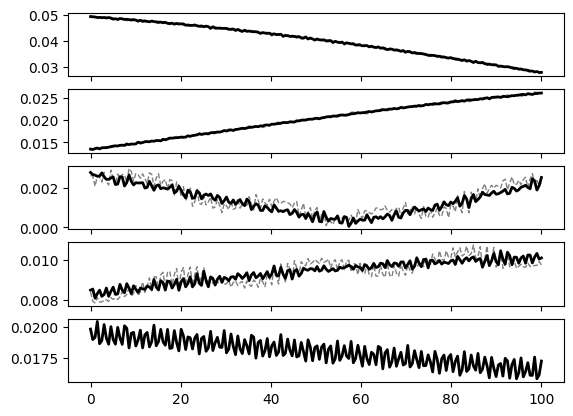

In [7]:
fig,axes = plt.subplots(nb_planets,1,sharex=True)
for i,ax in enumerate(axes):
    ax.plot(times,eccs_osc[i],ls='--',lw=1,color = 'gray')
    ax.plot(times,eccs_mean[i],ls='-',lw=2,color='black')
    

# Correcting multiple posterior samples

TODO: correct posteriors and convert to SFMR model